# 2. Modeling pipeline

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, RocCurveDisplay)
from xgboost import XGBClassifier
import os
import pickle
from datetime import datetime

input_file_path='./data/processed/customer_features.csv'

## Load data and select predictors
CSV does not preserve category data types, so set them again. Drop customers with no set labels. Use an explicit list of first purchase predictors so that future data does not leak into training.

In [37]:
categorical_columns = ['parent_region_id', 'child_region_id', 'product_code',
                       'acquired_by', 'purchase_weekday', 'acquisition_weekday']
numeric_columns = ['first_purchase_amount', 'days_to_first_purchase',
                   'purchase_hour', 'acquisition_hour']

data = pd.read_csv(input_file_path, dtype={c: str for c in ['customer_id'] + categorical_columns})
data = data.dropna(subset=['sticky_target']).copy()

for column in categorical_columns:
    data[column] = data[column].fillna('Unknown').astype('category')
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')
data['sticky_target'] = data['sticky_target'].astype(int)

X = data[numeric_columns + categorical_columns]
y = data['sticky_target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training: {len(X_train):,} customers | Test: {len(X_test):,} customers')

Training: 1,612 customers | Test: 403 customers


In [38]:
data['sticky_target'].value_counts()

sticky_target
1    1202
0     813
Name: count, dtype: int64

## Train Logistic Regression and XGBoost models
Fit imputing, scaling and encoding on training data only. Each model gets its own preprocessing pipeline.

In [39]:
models = {
    'Logistic regression': LogisticRegression(max_iter=1500, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=180, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=3,
                            eval_metric='logloss', n_jobs=2, random_state=42)
}

for name, estimator in models.items():
    preprocessing = ColumnTransformer([
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median')),
                              ('scale', StandardScaler())]), numeric_columns),
        ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=10), categorical_columns)
    ])
    models[name] = Pipeline([('preprocessing', preprocessing), ('model', estimator)])
    models[name].fit(X_train, y_train)
    print(f'{name} trained')

Logistic regression trained
XGBoost trained


## Evaluate training and test data
Classification metrics use probability ≥0.5. ROC-AUC and ROC curves use the probabilities. An always-sticky reference helps interpret results when most customers have target 1.

In [40]:
results = []
for name, model in models.items():
    for split, features, target in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        probability = model.predict_proba(features)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        results.append({
            'Model': name, 'Split': split,
            'Accuracy': accuracy_score(target, prediction),
            'Precision': precision_score(target, prediction, zero_division=0),
            'Recall': recall_score(target, prediction, zero_division=0),
            'F1': f1_score(target, prediction, zero_division=0),
            'ROC_AUC': roc_auc_score(target, probability)
        })

metrics = pd.DataFrame(results)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_folder = os.path.join('./experiments', f"experiment_{timestamp}")
os.makedirs(experiment_folder, exist_ok=True)
model_file=os.path.join(experiment_folder, 'metrics.csv')

metrics.to_csv(model_file, index=False)
metrics

,Model,Split,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic regression,Train,0.638958,0.647287,0.867983,0.741563,0.654401
1,Logistic regression,Test,0.607940,0.628125,0.837500,0.717857,0.595808
2,XGBoost,Train,0.701613,0.686869,0.918919,0.786127,0.799095
3,XGBoost,Test,0.627792,0.646104,0.829167,0.726277,0.612526


## Plot train and test ROC curves

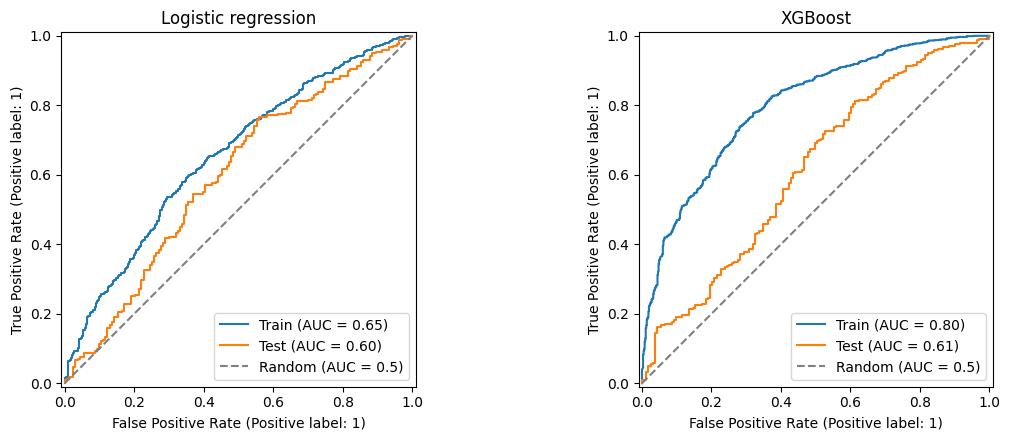

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    for split, features, target in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        RocCurveDisplay.from_predictions(
            target, model.predict_proba(features)[:, 1], name=split, ax=ax)
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.5)')
    ax.set_title(name)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

png_file=os.path.join(experiment_folder, 'roc_auc.png')
plt.savefig(png_file, dpi=300, bbox_inches="tight")
plt.close()

In [43]:
model_to_deploy='XGBoost' # or Logistic Regression

model_path = os.path.join('./app/', "model.pkl")
with open (model_path, 'wb') as f:
    pickle.dump(models[model_to_deploy], f)